# Cognifyz Data Science Internship
# Name: RAGHUL K
## Email ID: raghul1826@gmail.com
## Level 3 — Tasks 1, 2 & 3
**Dataset:** Zomato Restaurant Dataset  
**Level 3 covers:** Predictive Modeling | Customer Preference Analysis | Data Visualization

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.linear_model      import LinearRegression, Ridge
from sklearn.tree              import DecisionTreeRegressor
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline          import Pipeline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

print('All libraries loaded.')

All libraries loaded.


In [2]:
# ── Load & Full Preprocessing Pipeline ────────────────────────────────────────
df_raw = pd.read_csv("C:/Users/RAGHUL K/OneDrive/Documents/Jupyter/Dataset.csv")

df = df_raw.copy()
df['Cuisines'].fillna('Unknown', inplace=True)

# Binary encode
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Feature engineering (from Level 2)
df['Name Length']     = df['Restaurant Name'].str.len()
df['Address Length']  = df['Address'].str.len()
df['Cuisine Count']   = df['Cuisines'].str.split(',').str.len()

print(f'Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(2)

Dataset ready: 9551 rows × 24 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Name Length,Address Length,Cuisine Count
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,0,0,3,4.8,Dark Green,Excellent,314,16,71,3.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,0,0,3,4.5,Dark Green,Excellent,591,16,67,1.0


---
## Task 1 — Predictive Modeling

### 1.1 — Prepare Features and Target

In [14]:
# 1. Drop rows where your target variable is missing (you cannot train on missing targets)
df = df.dropna(subset=['Aggregate rating'])

# 2. Fill missing numerical values with the median
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3. Fill missing categorical/text values (like 'Cuisines') with a placeholder
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# Only use rated restaurants for regression
model_df = df[df['Aggregate rating'] > 0].copy()

# Select features
feature_cols = [
    'Country Code', 'Average Cost for two', 'Price range', 'Votes',
    'Has Table booking', 'Has Online delivery', 'Is delivering now',
    'Name Length', 'Address Length', 'Cuisine Count'
]

X = model_df[feature_cols]
y = model_df['Aggregate rating']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Rating range   : {y.min():.1f} → {y.max():.1f}')

Features shape : (7403, 10)
Target shape   : (7403,)
Rating range   : 1.8 → 4.9


### 1.2 — Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train['Cuisine Count'].fillna(X_train['Cuisine Count'].median(), inplace=True)
print(f'Train size: {X_train.shape[0]}')
print(f'Test  size: {X_test.shape[0]}')

Train size: 5922
Test  size: 1481


### 1.3 — Train Multiple Models and Compare

In [16]:
models = {
    'Linear Regression' : Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge Regression'  : Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})
    print(f'{name:<22} | MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n── Model Ranking by R² ──')
print(results_df.to_string(index=False))

Linear Regression      | MAE=0.3439  RMSE=0.4365  R²=0.3838
Ridge Regression       | MAE=0.3439  RMSE=0.4365  R²=0.3838
Decision Tree          | MAE=0.2796  RMSE=0.3792  R²=0.5352
Random Forest          | MAE=0.2675  RMSE=0.3618  R²=0.5769
Gradient Boosting      | MAE=0.2657  RMSE=0.3573  R²=0.5872

── Model Ranking by R² ──
            Model    MAE   RMSE     R²
Gradient Boosting 0.2657 0.3573 0.5872
    Random Forest 0.2675 0.3618 0.5769
    Decision Tree 0.2796 0.3792 0.5352
Linear Regression 0.3439 0.4365 0.3838
 Ridge Regression 0.3439 0.4365 0.3838


### 1.4 — Visual Model Comparison

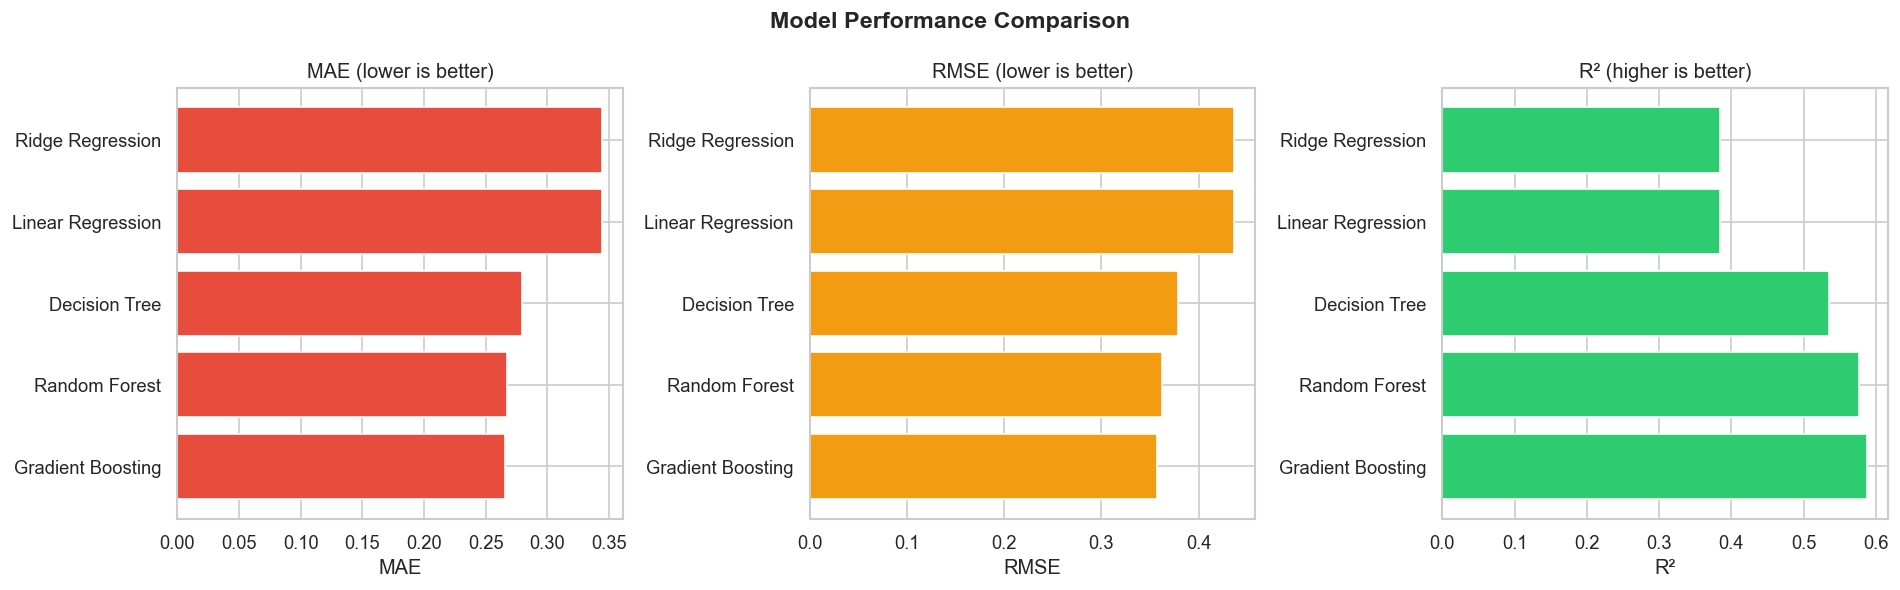

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R²']
colors  = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    data = results_df.sort_values(metric, ascending=(metric != 'R²'))
    ax.barh(data['Model'], data[metric], color=color, edgecolor='white')
    ax.set_title(f'{metric} (lower is better)' if metric != 'R²' else f'{metric} (higher is better)')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

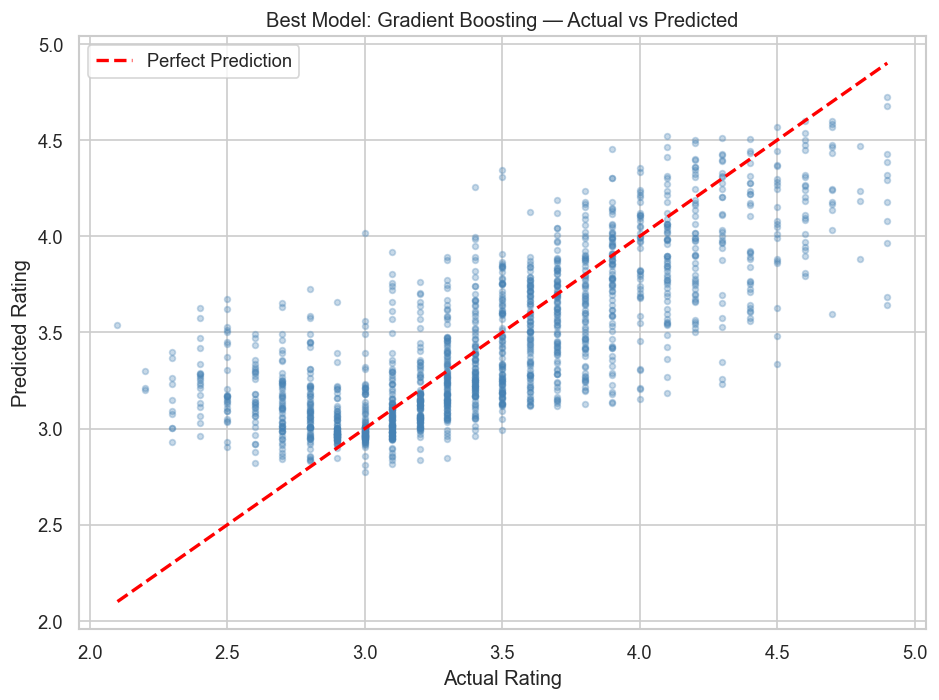

In [18]:
# Best model: Predicted vs Actual scatter
best_model_name = results_df.iloc[0]['Model']
best_preds      = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_preds, alpha=0.3, s=12, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title(f'Best Model: {best_model_name} — Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.show()

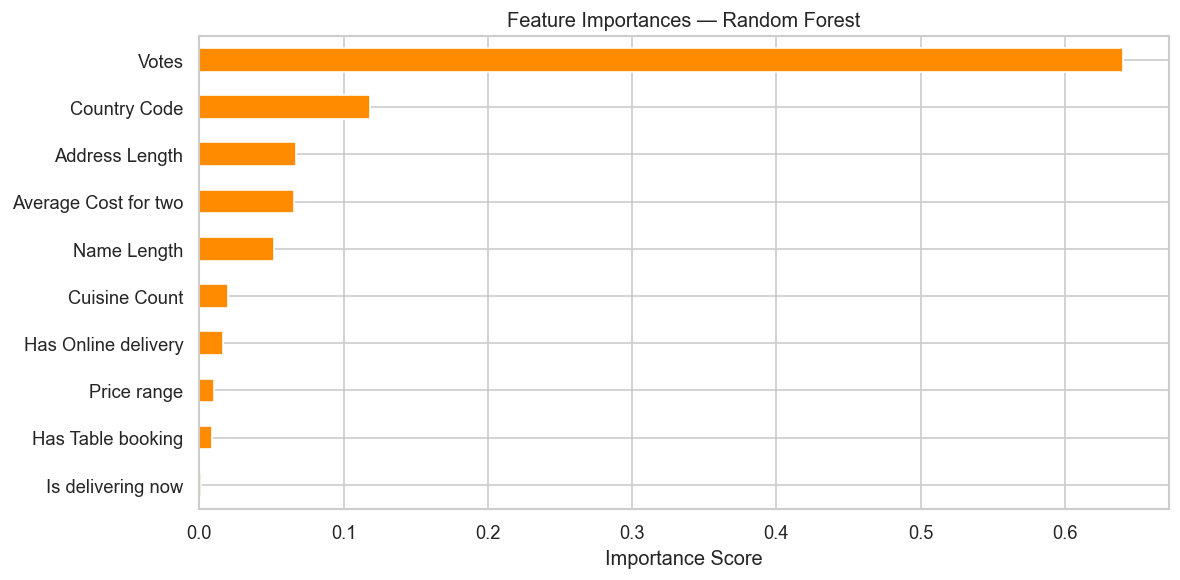

Votes                   0.6400
Country Code            0.1186
Address Length          0.0672
Average Cost for two    0.0659
Name Length             0.0515
Cuisine Count           0.0202
Has Online delivery     0.0163
Price range             0.0104
Has Table booking       0.0091
Is delivering now       0.0009
dtype: float64


In [19]:
# Feature Importance (Random Forest)
rf_model = models['Random Forest'].fit(X_train, y_train)
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances.round(4))

---
## Task 2 — Customer Preference Analysis

### 2.1 — Cuisine vs Rating Relationship

In [20]:
rated = df[df['Aggregate rating'] > 0].copy()

# Explode multi-cuisine rows
cuisine_exploded = rated.copy()
cuisine_exploded['Cuisines'] = cuisine_exploded['Cuisines'].str.split(', ')
cuisine_exploded = cuisine_exploded.explode('Cuisines')
cuisine_exploded['Cuisines'] = cuisine_exploded['Cuisines'].str.strip()

cuisine_stats = (
    cuisine_exploded.groupby('Cuisines')
    .agg(avg_rating=('Aggregate rating', 'mean'),
         total_votes=('Votes', 'sum'),
         count=('Restaurant ID', 'count'))
    .reset_index()
    .query('count >= 20')          # minimum threshold for reliability
    .sort_values('avg_rating', ascending=False)
)

print('Top 10 Cuisines by Average Rating:')
print(cuisine_stats.head(10).to_string(index=False))

Top 10 Cuisines by Average Rating:
     Cuisines  avg_rating  total_votes  count
    Brazilian    4.343478         3252     23
International    4.247619         8122     21
       Indian    4.156061        22391     66
     Bar Food    4.145946        15681     37
     Southern    4.129167        13939     24
   Vegetarian    4.073913        10714     23
     Sandwich    4.066038        23500     53
        Grill    4.057143         4301     21
          BBQ    4.025000         9645     32
Mediterranean    4.020000        80532    110


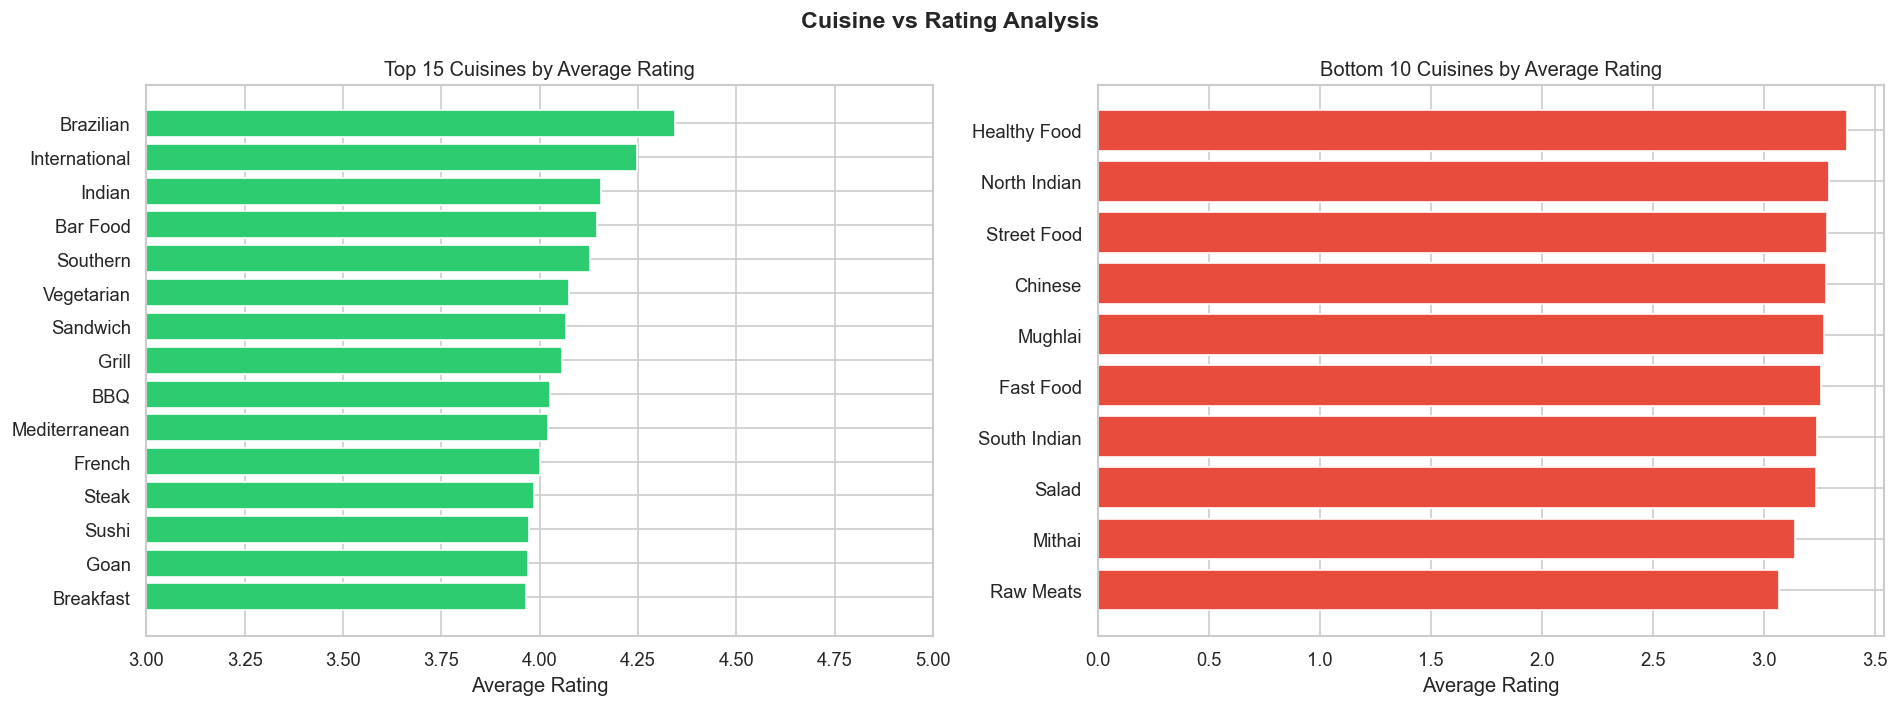

In [21]:
top_rated_cuisines   = cuisine_stats.head(15)
bottom_rated_cuisines = cuisine_stats.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 by rating
axes[0].barh(top_rated_cuisines['Cuisines'][::-1],
             top_rated_cuisines['avg_rating'][::-1],
             color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 15 Cuisines by Average Rating')
axes[0].set_xlabel('Average Rating')
axes[0].set_xlim(3.0, 5.0)

# Bottom 10 by rating
axes[1].barh(bottom_rated_cuisines['Cuisines'][::-1],
             bottom_rated_cuisines['avg_rating'][::-1],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Bottom 10 Cuisines by Average Rating')
axes[1].set_xlabel('Average Rating')

plt.suptitle('Cuisine vs Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 — Most Popular Cuisines by Votes

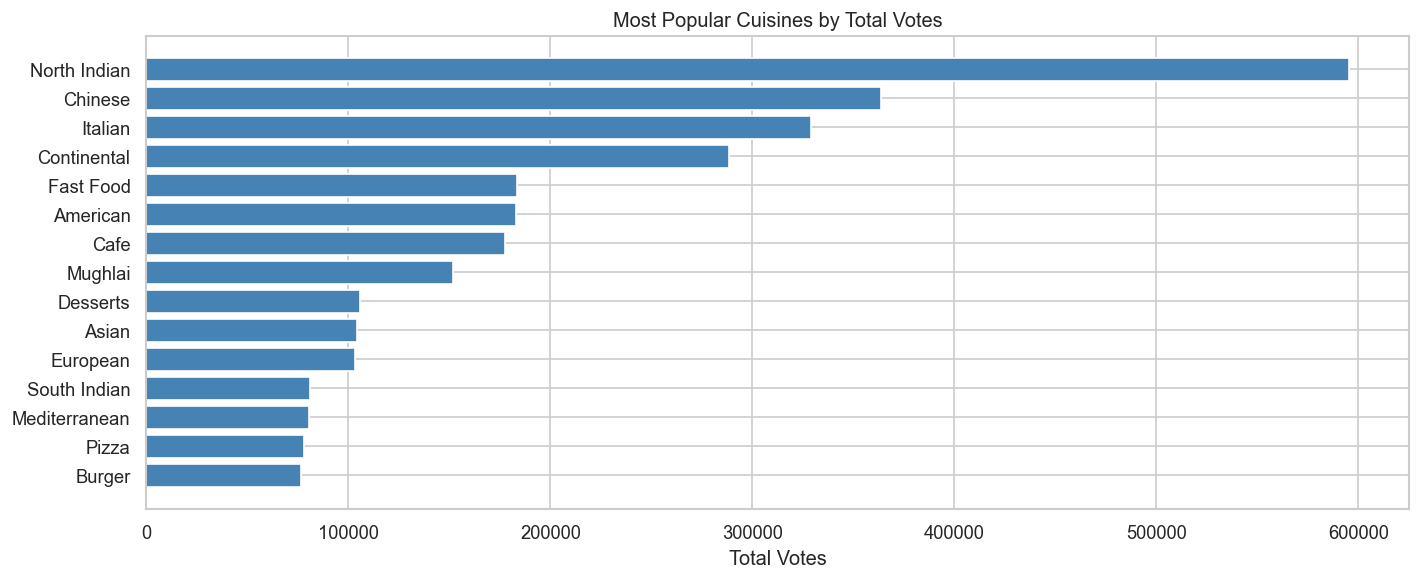

     Cuisines  total_votes  avg_rating
 North Indian       595194    3.295128
      Chinese       363890    3.282280
      Italian       329230    3.748485
  Continental       288213    3.705007
    Fast Food       183665    3.256750
     American       183106    3.757895
         Cafe       177494    3.682650
      Mughlai       151784    3.270655
     Desserts       105781    3.582320
        Asian       104298    3.898684
     European       103305    3.964384
 South Indian        80822    3.238763
Mediterranean        80532    4.020000
        Pizza        78128    3.393902
       Burger        76734    3.697490


In [22]:
most_voted = cuisine_stats.sort_values('total_votes', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(most_voted['Cuisines'][::-1], most_voted['total_votes'][::-1],
               color='steelblue', edgecolor='white')
ax.set_title('Most Popular Cuisines by Total Votes')
ax.set_xlabel('Total Votes')
plt.tight_layout()
plt.show()

print(most_voted[['Cuisines', 'total_votes', 'avg_rating']].to_string(index=False))

### 2.3 — Cuisines Receiving Consistently High Ratings

Cuisines consistently rated above 4.0 (min 30 restaurants): 5
     Cuisines  avg_rating  count  total_votes
       Indian    4.156061     66        22391
     Bar Food    4.145946     37        15681
     Sandwich    4.066038     53        23500
          BBQ    4.025000     32         9645
Mediterranean    4.020000    110        80532


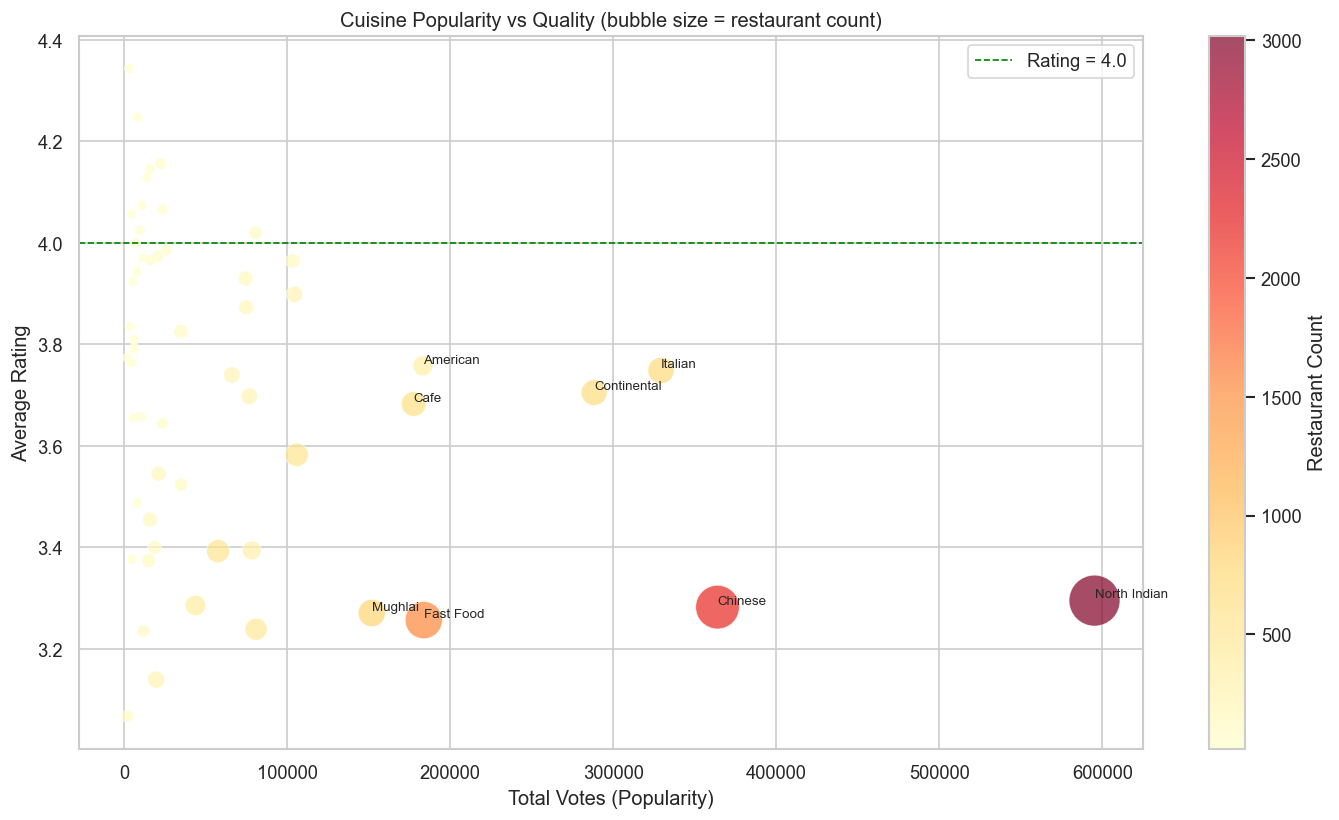

In [23]:
# High-rating cuisines: avg > 4.0 AND count >= 30
high_rated = cuisine_stats[(cuisine_stats['avg_rating'] > 4.0) & (cuisine_stats['count'] >= 30)]

print(f'Cuisines consistently rated above 4.0 (min 30 restaurants): {len(high_rated)}')
print(high_rated[['Cuisines', 'avg_rating', 'count', 'total_votes']].to_string(index=False))

# Scatter: votes vs rating
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    cuisine_stats['total_votes'],
    cuisine_stats['avg_rating'],
    c=cuisine_stats['count'],
    cmap='YlOrRd',
    s=cuisine_stats['count'] * 0.3 + 30,
    alpha=0.7,
    edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, label='Restaurant Count')

# Annotate top cuisines
top_ann = cuisine_stats.nlargest(8, 'total_votes')
for _, row in top_ann.iterrows():
    ax.annotate(row['Cuisines'],
                (row['total_votes'], row['avg_rating']),
                fontsize=8, ha='left', va='bottom')

ax.axhline(4.0, color='green', linestyle='--', linewidth=1, label='Rating = 4.0')
ax.set_xlabel('Total Votes (Popularity)')
ax.set_ylabel('Average Rating')
ax.set_title('Cuisine Popularity vs Quality (bubble size = restaurant count)')
ax.legend()
plt.tight_layout()
plt.show()

**Key Finding:** North Indian and Chinese cuisines dominate in popularity (vote count), while specialty cuisines like Cafe and Continental tend to score higher average ratings.

---
## Task 3 — Data Visualization

### 3.1 — Rating Distribution (Multiple Chart Types)

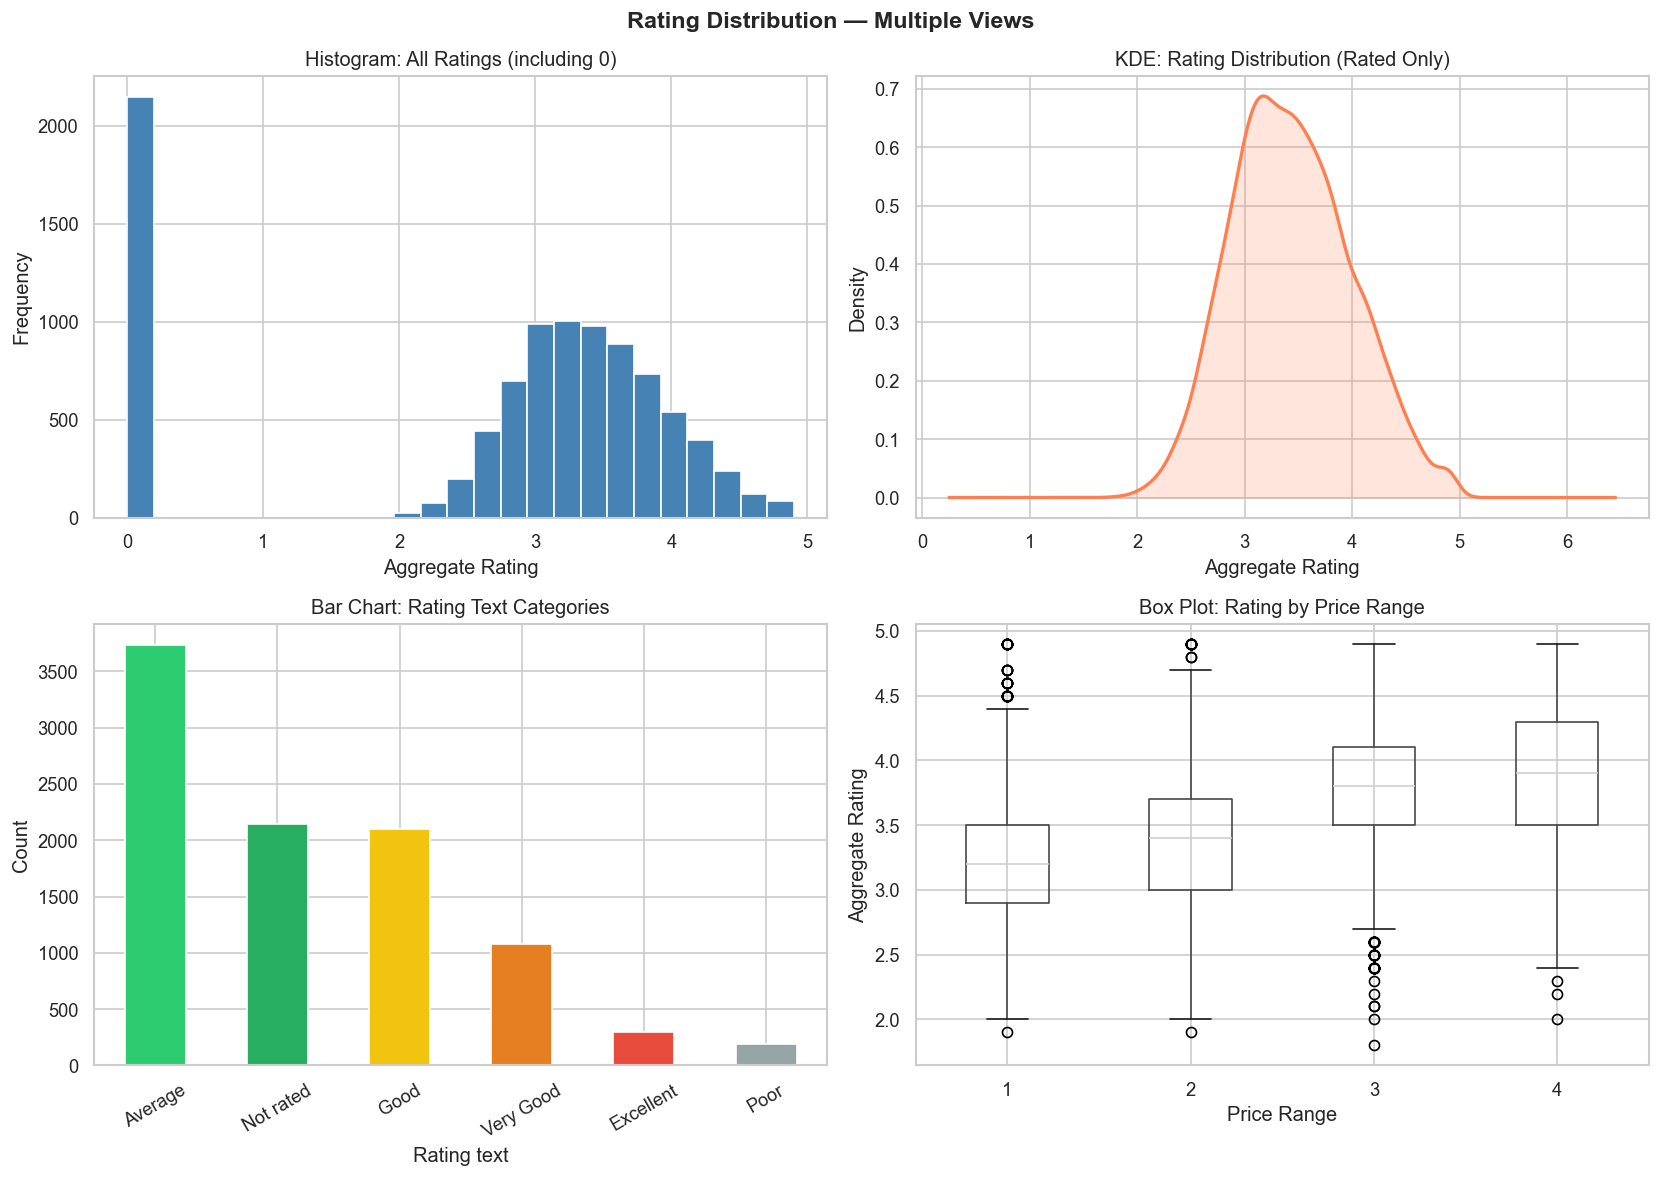

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of all ratings
axes[0, 0].hist(df['Aggregate rating'], bins=25, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Histogram: All Ratings (including 0)')
axes[0, 0].set_xlabel('Aggregate Rating')
axes[0, 0].set_ylabel('Frequency')

# 2. KDE of rated-only
rated_vals = df[df['Aggregate rating'] > 0]['Aggregate rating']
rated_vals.plot(kind='kde', ax=axes[0, 1], color='coral', linewidth=2)
axes[0, 1].fill_between(axes[0, 1].lines[0].get_xdata(),
                         axes[0, 1].lines[0].get_ydata(), alpha=0.2, color='coral')
axes[0, 1].set_title('KDE: Rating Distribution (Rated Only)')
axes[0, 1].set_xlabel('Aggregate Rating')

# 3. Bar chart of Rating Text categories
rating_text_counts = df['Rating text'].value_counts()
rating_text_counts.plot(kind='bar', ax=axes[1, 0],
                         color=['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6'],
                         edgecolor='white')
axes[1, 0].set_title('Bar Chart: Rating Text Categories')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Box plot across price ranges
df[df['Aggregate rating'] > 0].boxplot(
    column='Aggregate rating', by='Price range', ax=axes[1, 1]
)
axes[1, 1].set_title('Box Plot: Rating by Price Range')
axes[1, 1].set_xlabel('Price Range')
axes[1, 1].set_ylabel('Aggregate Rating')
plt.suptitle('Rating Distribution — Multiple Views', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 — Average Ratings by Cuisine and City

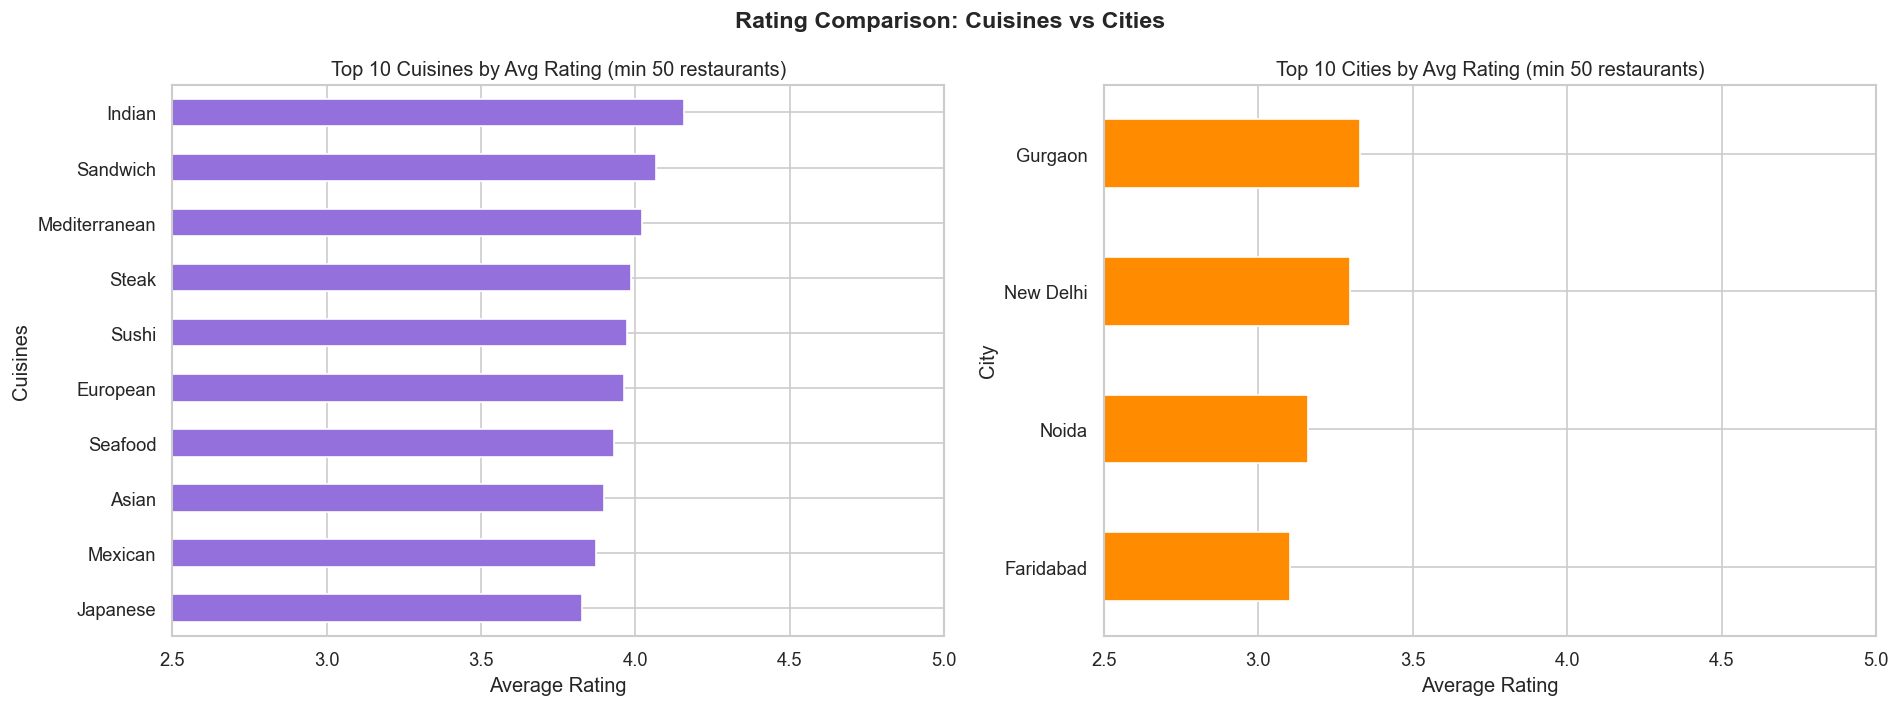

In [26]:
rated = df[df['Aggregate rating'] > 0]

# Top 10 cuisines by avg rating (min 50 restaurants)
top_cuisine_ratings = (
    cuisine_exploded.groupby('Cuisines')['Aggregate rating']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean', ascending=False)
    .head(10)
)

# Top 10 cities by avg rating (min 50 restaurants)
top_city_ratings = (
    rated.groupby('City')['Aggregate rating']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cuisine_ratings['mean'].plot(kind='barh', ax=axes[0],
                                  color='mediumpurple', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Cuisines by Avg Rating (min 50 restaurants)')
axes[0].set_xlabel('Average Rating')
axes[0].set_xlim(2.5, 5.0)

top_city_ratings['mean'].plot(kind='barh', ax=axes[1],
                               color='darkorange', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Cities by Avg Rating (min 50 restaurants)')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(2.5, 5.0)

plt.suptitle('Rating Comparison: Cuisines vs Cities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 — Feature Correlation Heatmap

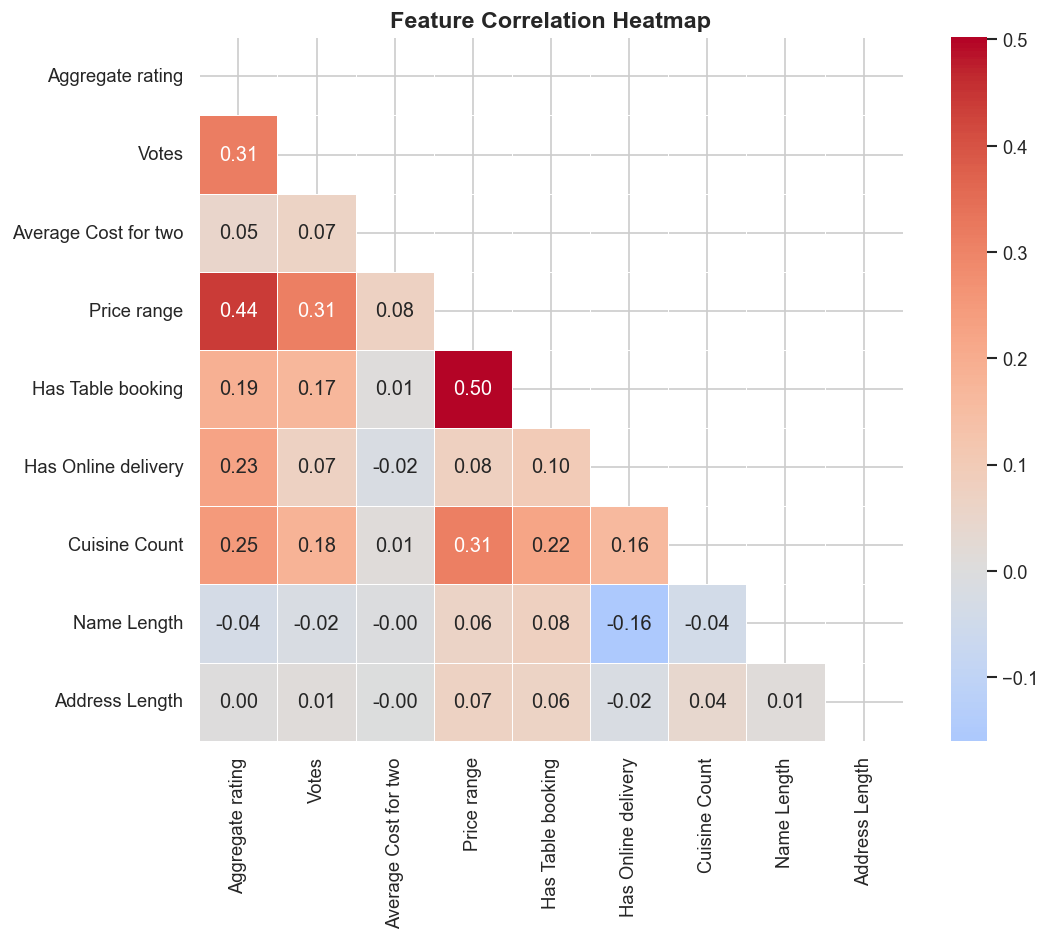

In [27]:
heatmap_cols = [
    'Aggregate rating', 'Votes', 'Average Cost for two',
    'Price range', 'Has Table booking', 'Has Online delivery',
    'Cuisine Count', 'Name Length', 'Address Length'
]
corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 — Votes vs Aggregate Rating

Pearson r (Votes vs Rating)      : 0.4090
Pearson r (log(Votes) vs Rating) : 0.6490


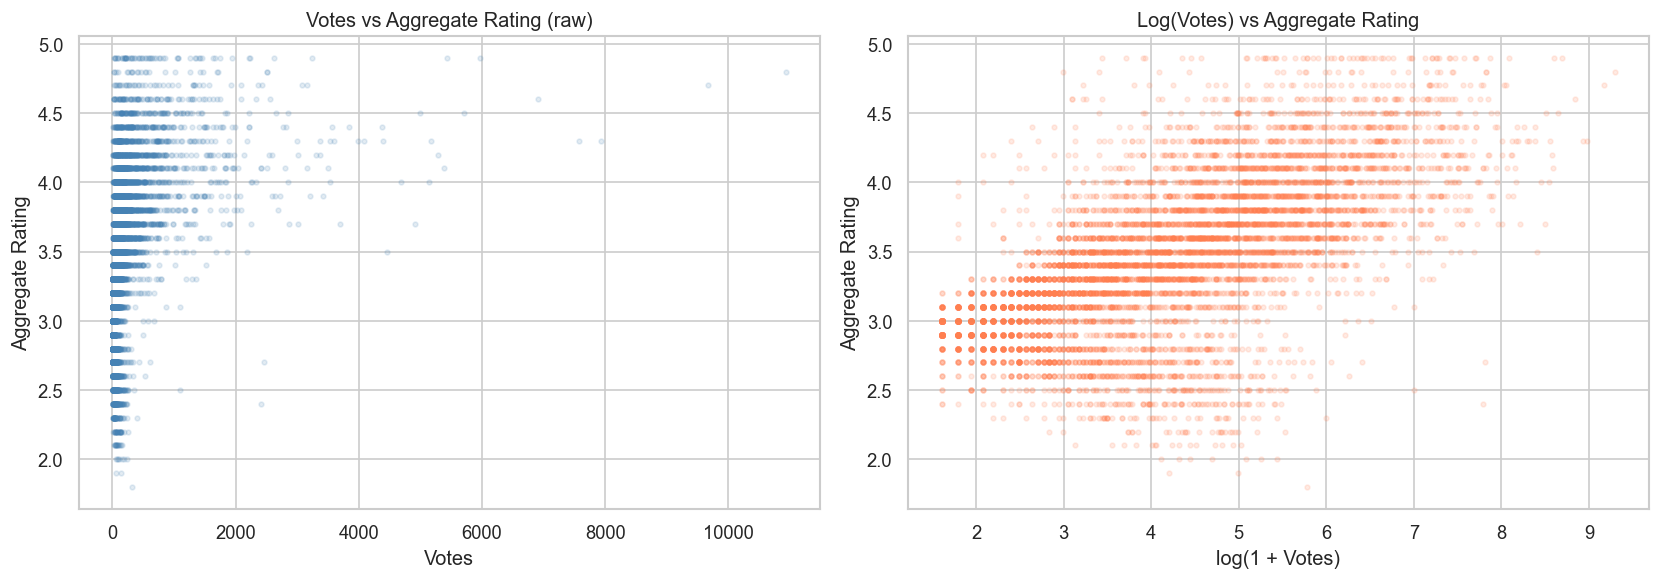

In [28]:
rated = df[df['Aggregate rating'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scatter
axes[0].scatter(rated['Votes'], rated['Aggregate rating'],
                alpha=0.15, s=8, color='steelblue')
axes[0].set_title('Votes vs Aggregate Rating (raw)')
axes[0].set_xlabel('Votes')
axes[0].set_ylabel('Aggregate Rating')

# Log-scaled votes
axes[1].scatter(np.log1p(rated['Votes']), rated['Aggregate rating'],
                alpha=0.15, s=8, color='coral')
axes[1].set_title('Log(Votes) vs Aggregate Rating')
axes[1].set_xlabel('log(1 + Votes)')
axes[1].set_ylabel('Aggregate Rating')

corr_raw = rated['Votes'].corr(rated['Aggregate rating'])
corr_log = np.log1p(rated['Votes']).corr(rated['Aggregate rating'])
print(f'Pearson r (Votes vs Rating)      : {corr_raw:.4f}')
print(f'Pearson r (log(Votes) vs Rating) : {corr_log:.4f}')

plt.tight_layout()
plt.show()

### 3.5 — Pairplot: Key Features vs Rating

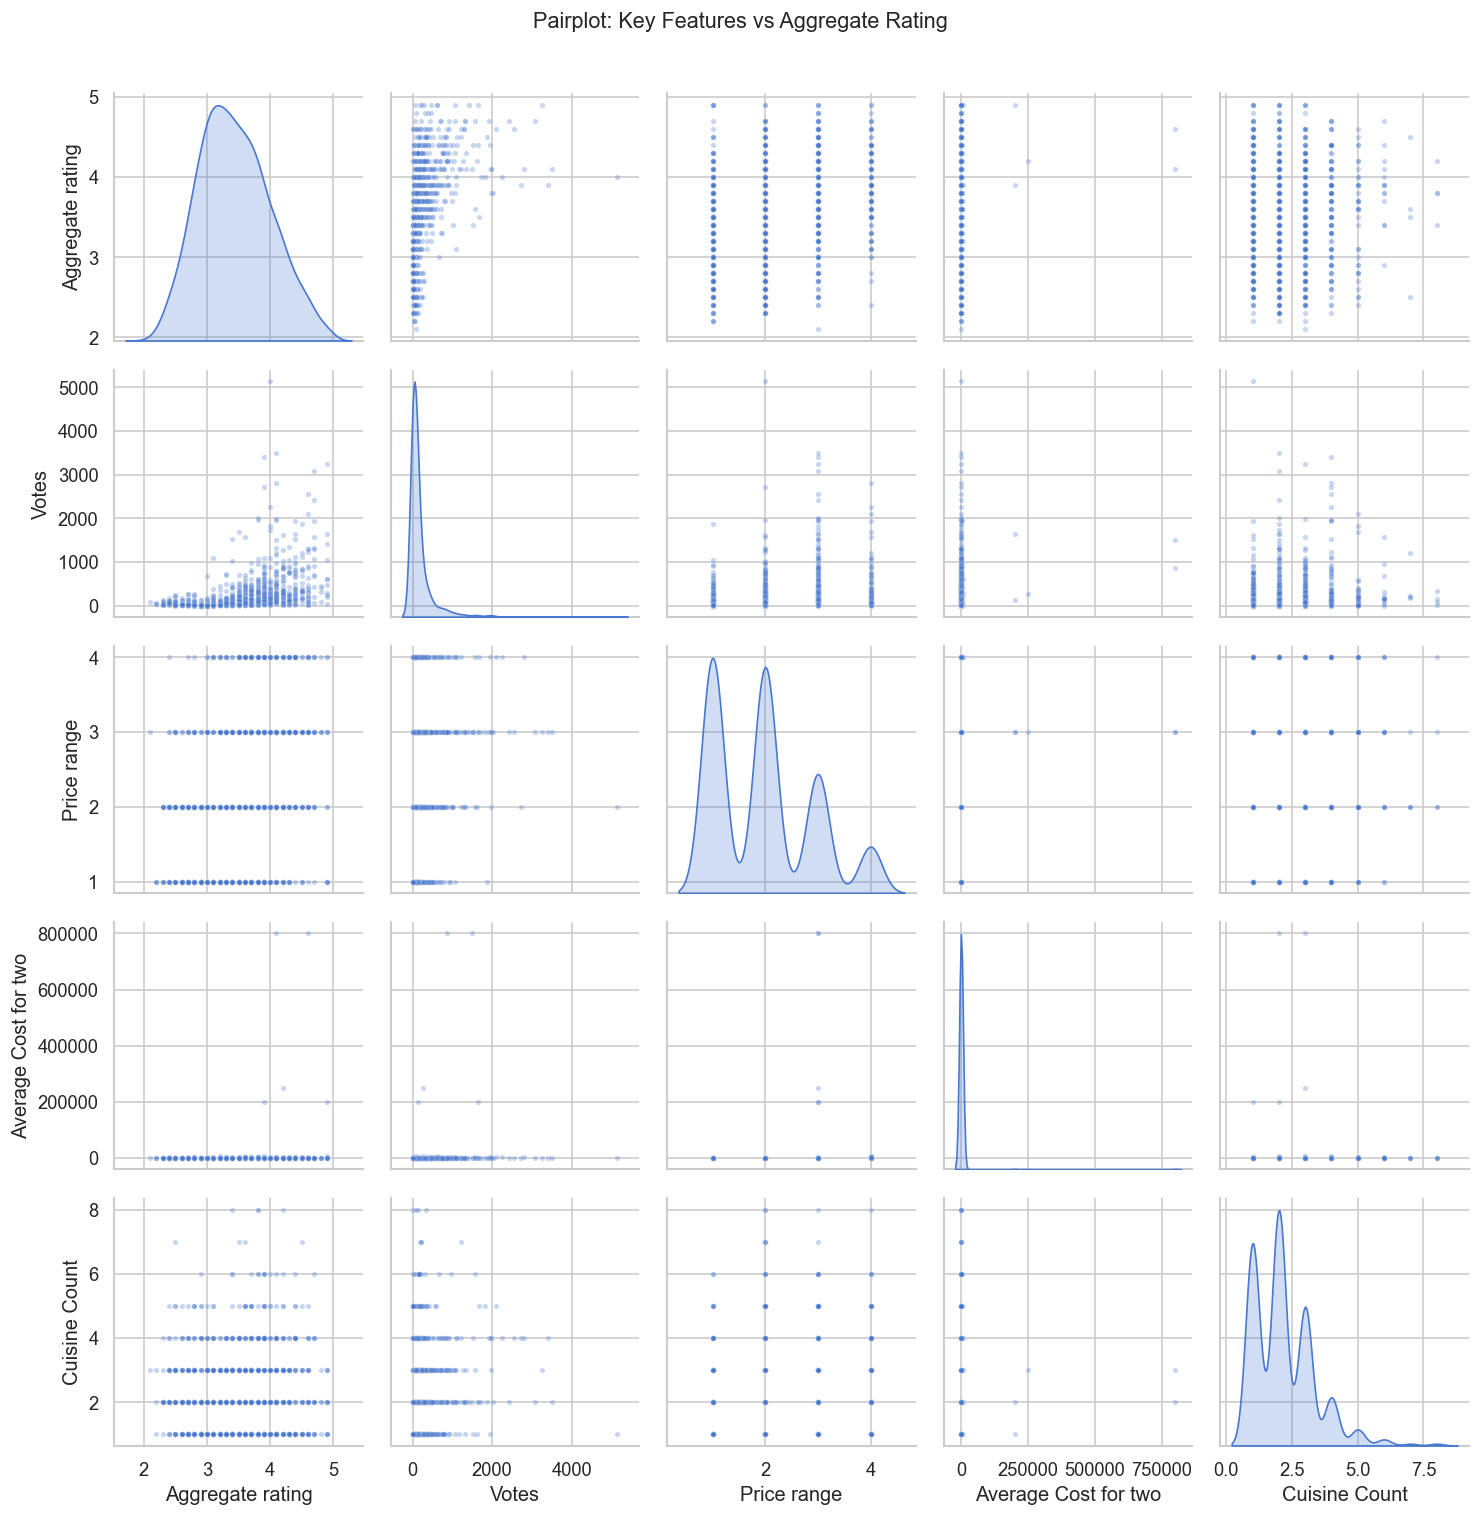

In [29]:
pair_cols = ['Aggregate rating', 'Votes', 'Price range', 'Average Cost for two', 'Cuisine Count']
pair_df   = df[df['Aggregate rating'] > 0][pair_cols].sample(n=1500, random_state=42)

pair_grid = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
                          diag_kws={'fill': True})
pair_grid.fig.suptitle('Pairplot: Key Features vs Aggregate Rating', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
print('='*55)
print('Level 3 Complete ✓')
print('='*55)
print(f'Best Model        : {best_model_name}')
best_r2 = results_df.iloc[0]['R²']
print(f'Best R² Score     : {best_r2}')
print(f'Top Cuisine (votes): {most_voted.iloc[0]["Cuisines"]}')
print('Notebooks for all 3 levels are complete!')

Level 3 Complete ✓
Best Model        : Gradient Boosting
Best R² Score     : 0.5872
Top Cuisine (votes): North Indian
Notebooks for all 3 levels are complete!
